In [ ]:
!git clone https://github.com/nareshmeena12/sustainable-portfolio-optimizer.git
%cd sustainable-portfolio-optimizer

Cloning into 'sustainable-portfolio-optimizer'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 43 (delta 0), reused 40 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 1.18 MiB | 17.04 MiB/s, done.
/content/sustainable-portfolio-optimizer


In [ ]:
!pip install pandas numpy matplotlib seaborn pickle5 -q

### **Imports**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"]      = 120
plt.rcParams["font.family"]     = "sans-serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

###Loading the raw data we downloaded — 1480 trading days, 12 stocks, zero missing values. Clean.



In [ ]:
prices  = pd.read_csv("data/raw/prices_close.csv", index_col=0, parse_dates=True)
esg_df  = pd.read_csv("data/raw/esg_scores.csv",  index_col=0)
sectors = pd.read_csv("data/raw/sector_map.csv",  index_col=0)

print(f"Price data   : {prices.shape[0]} days x {prices.shape[1]} stocks")
print(f"Date range   : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"ESG tickers  : {list(esg_df.index)}")
print(f"Missing vals : {prices.isna().sum().sum()}")
print()
print(prices.tail(3))

Price data   : 1480 days x 12 stocks
Date range   : 2019-01-01 to 2024-12-30
ESG tickers  : ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS', 'RELIANCE.NS', 'ONGC.NS', 'TATAPOWER.NS', 'ADANIGREEN.NS', 'SUNPHARMA.NS', 'DRREDDY.NS', 'CIPLA.NS', 'DIVISLAB.NS']
Missing vals : 0

                 TCS.NS      INFY.NS    WIPRO.NS   HCLTECH.NS  RELIANCE.NS  \
Date                                                                         
2024-12-26  3957.020752  1852.574341  285.954041  1817.951538  1211.710571   
2024-12-27  3952.987061  1861.655518  289.750519  1809.582642  1216.192749   
2024-12-30  3947.244629  1851.214478  284.688568  1844.922852  1205.883789   

               ONGC.NS  TATAPOWER.NS  ADANIGREEN.NS  SUNPHARMA.NS  \
Date                                                                
2024-12-26  223.465378    401.934448    1064.250000   1812.539917   
2024-12-27  220.349411    396.665466    1054.000000   1832.128662   
2024-12-30  216.396332    387.469574    1075.650024   1854.

### Price trends across all 3 sectors, normalized to 100 at start so we can compare stocks on the same scale. The dashed line marks where training ends and testing begins.

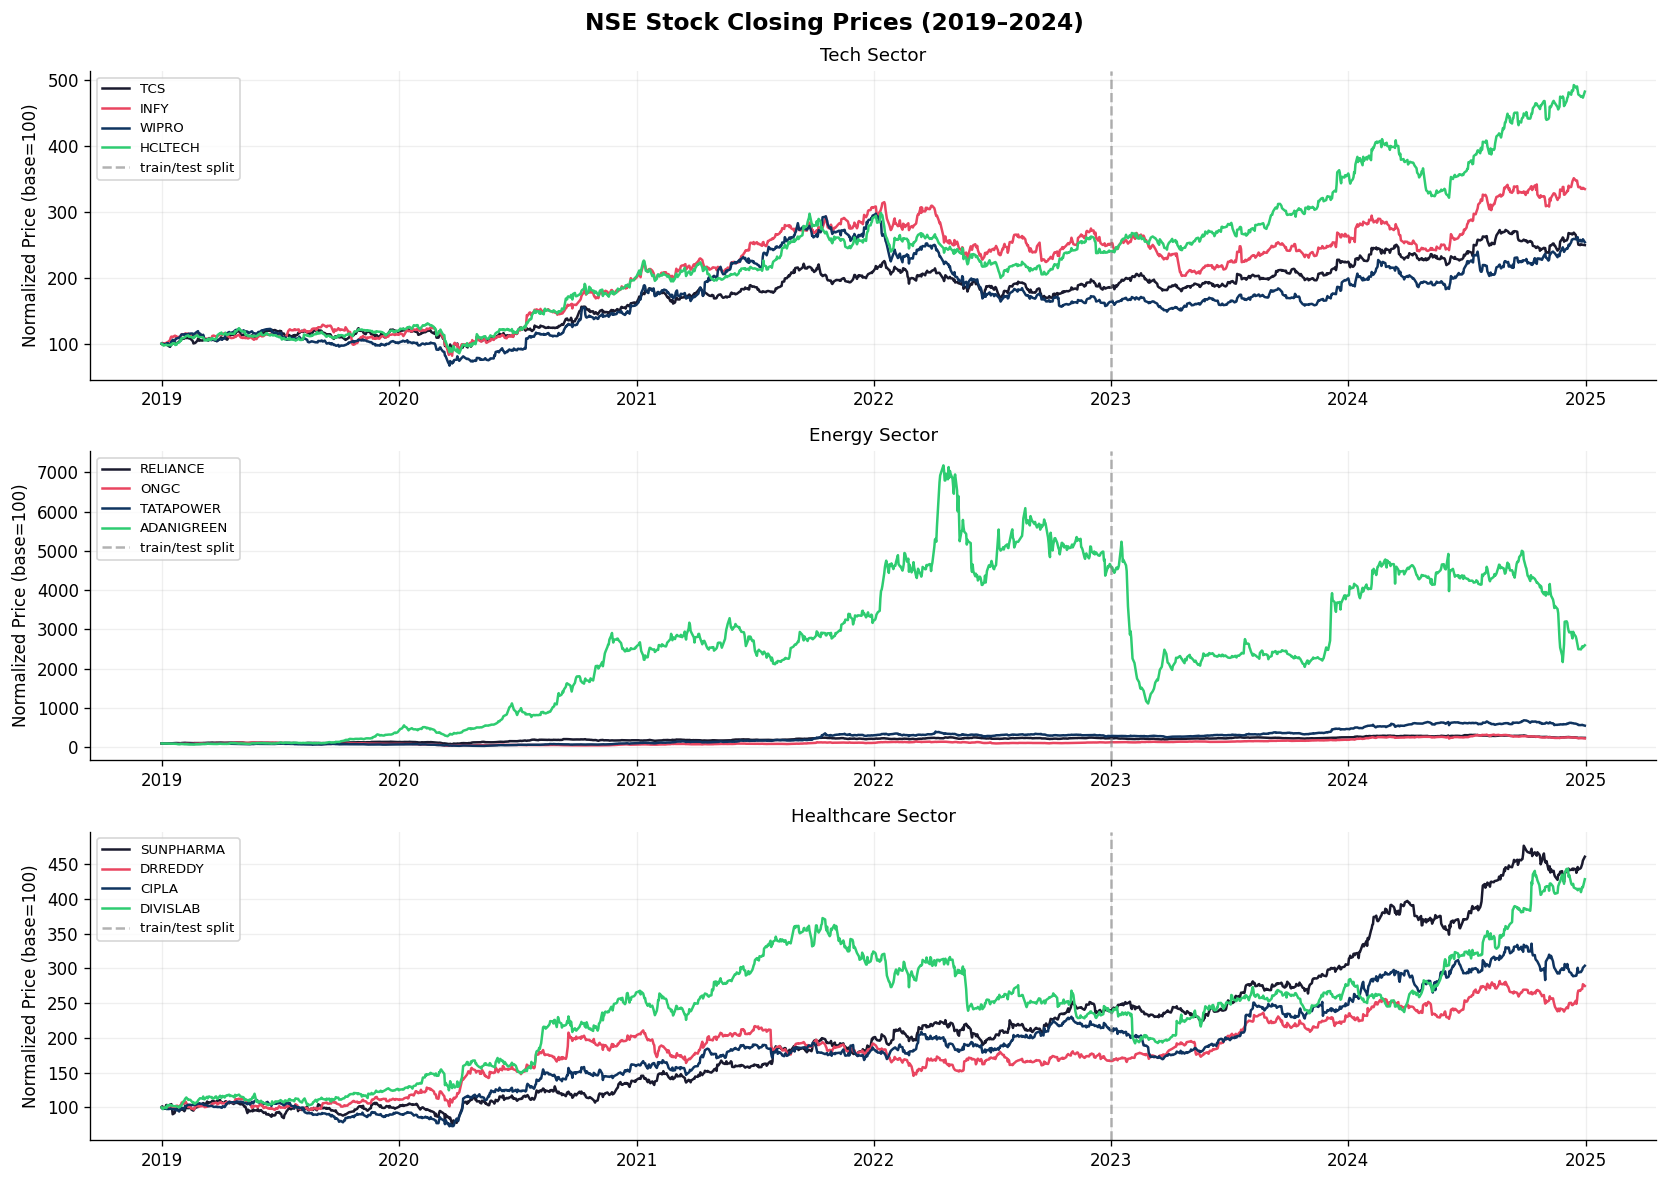

In [ ]:
sector_groups = {
    "Tech"      : ["TCS.NS", "INFY.NS", "WIPRO.NS", "HCLTECH.NS"],
    "Energy"    : ["RELIANCE.NS", "ONGC.NS", "TATAPOWER.NS", "ADANIGREEN.NS"],
    "Healthcare": ["SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS", "DIVISLAB.NS"],
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("NSE Stock Closing Prices (2019–2024)", fontsize=14, fontweight="bold")
import os
os.makedirs("logs/plots", exist_ok=True)
colors = ["#1A1A2E", "#E94560", "#0F3460", "#2ECC71"]

for ax, (sector, tickers) in zip(axes, sector_groups.items()):
    for ticker, color in zip(tickers, colors):
        # normalize to 100 at start so all stocks are comparable
        normalized = prices[ticker] / prices[ticker].iloc[0] * 100
        ax.plot(normalized, label=ticker.replace(".NS", ""),
                color=color, linewidth=1.5)

    ax.set_title(f"{sector} Sector", fontsize=11)
    ax.set_ylabel("Normalized Price (base=100)")
    ax.axvline(pd.Timestamp("2023-01-01"), color="gray",
               linestyle="--", alpha=0.6, label="train/test split")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("logs/plots/closing_prices.png", dpi=150)
plt.show()

### How daily returns are distributed for each stock — tells us about volatility and tail risk across sectors.

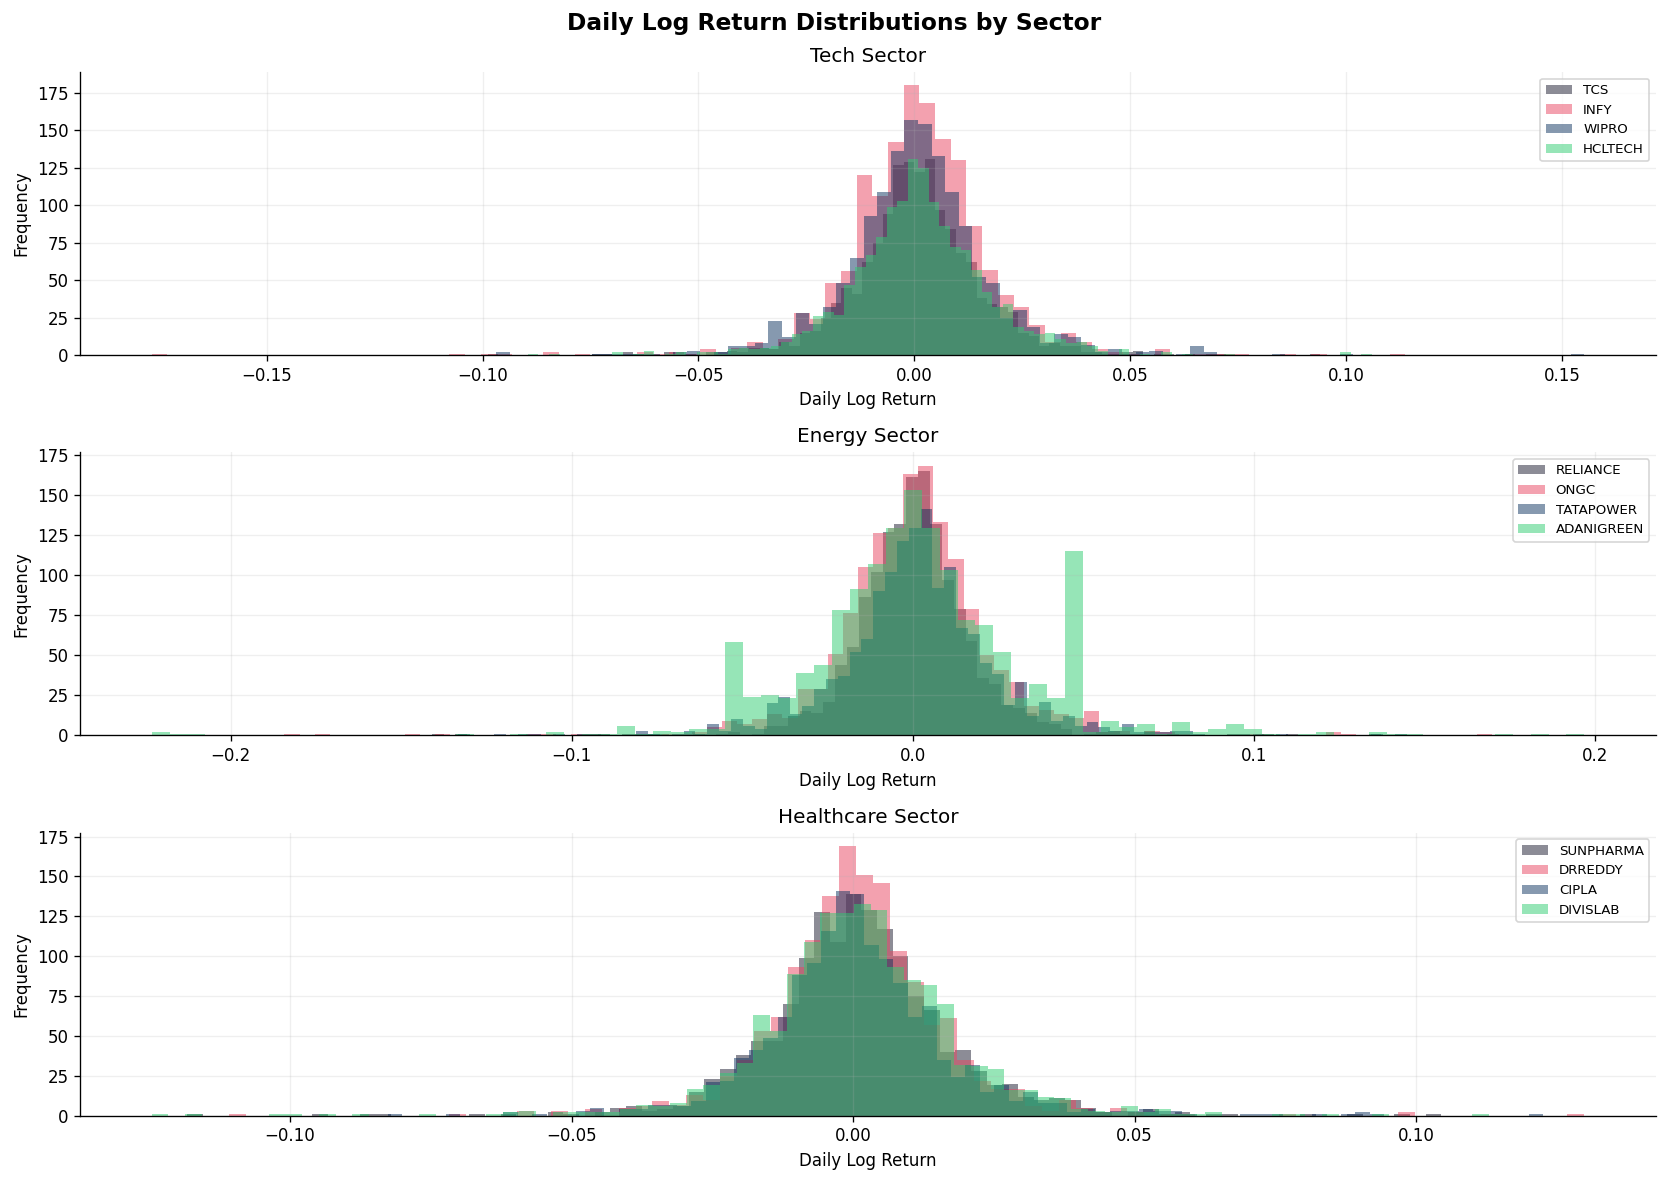


Return Statistics:
                  mean      std     skew
TCS.NS         0.00062  0.01525 -0.12296
INFY.NS        0.00082  0.01763 -0.79059
WIPRO.NS       0.00063  0.01768  0.51591
HCLTECH.NS     0.00106  0.01686  0.13755
RELIANCE.NS    0.00060  0.01841  0.11770
ONGC.NS        0.00056  0.02357 -0.37374
TATAPOWER.NS   0.00116  0.02423 -0.02639
ADANIGREEN.NS  0.00220  0.03466 -0.08884
SUNPHARMA.NS   0.00103  0.01687  0.05056
DRREDDY.NS     0.00068  0.01566  0.45196
CIPLA.NS       0.00075  0.01687  0.89058
DIVISLAB.NS    0.00098  0.01826 -0.36796


In [ ]:
log_returns = np.log(prices / prices.shift(1)).dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Daily Log Return Distributions by Sector", fontsize=14, fontweight="bold")

for ax, (sector, tickers) in zip(axes, sector_groups.items()):
    for ticker, color in zip(tickers, colors):
        ax.hist(log_returns[ticker], bins=80, alpha=0.5,
                label=ticker.replace(".NS", ""), color=color)

    ax.set_title(f"{sector} Sector")
    ax.set_xlabel("Daily Log Return")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("logs/plots/return_distributions.png", dpi=150)
plt.show()

# print stats
print("\nReturn Statistics:")
print(log_returns.agg(["mean", "std", "skew"]).T.round(5))

### ADANIGREEN has the highest average daily return (0.22%) but also the highest volatility (3.4%) — classic high risk high reward. ONGC is the most volatile in energy with lowest return, which explains why our agents learn to avoid it.

### Within-sector correlations are strong (0.57–0.65 for tech, 0.38–0.46 for healthcare) while cross-sector correlations are weak (0.06–0.35). This directly justifies our multi-agent design — each agent specializes in one sector without being confused by unrelated stock movements.

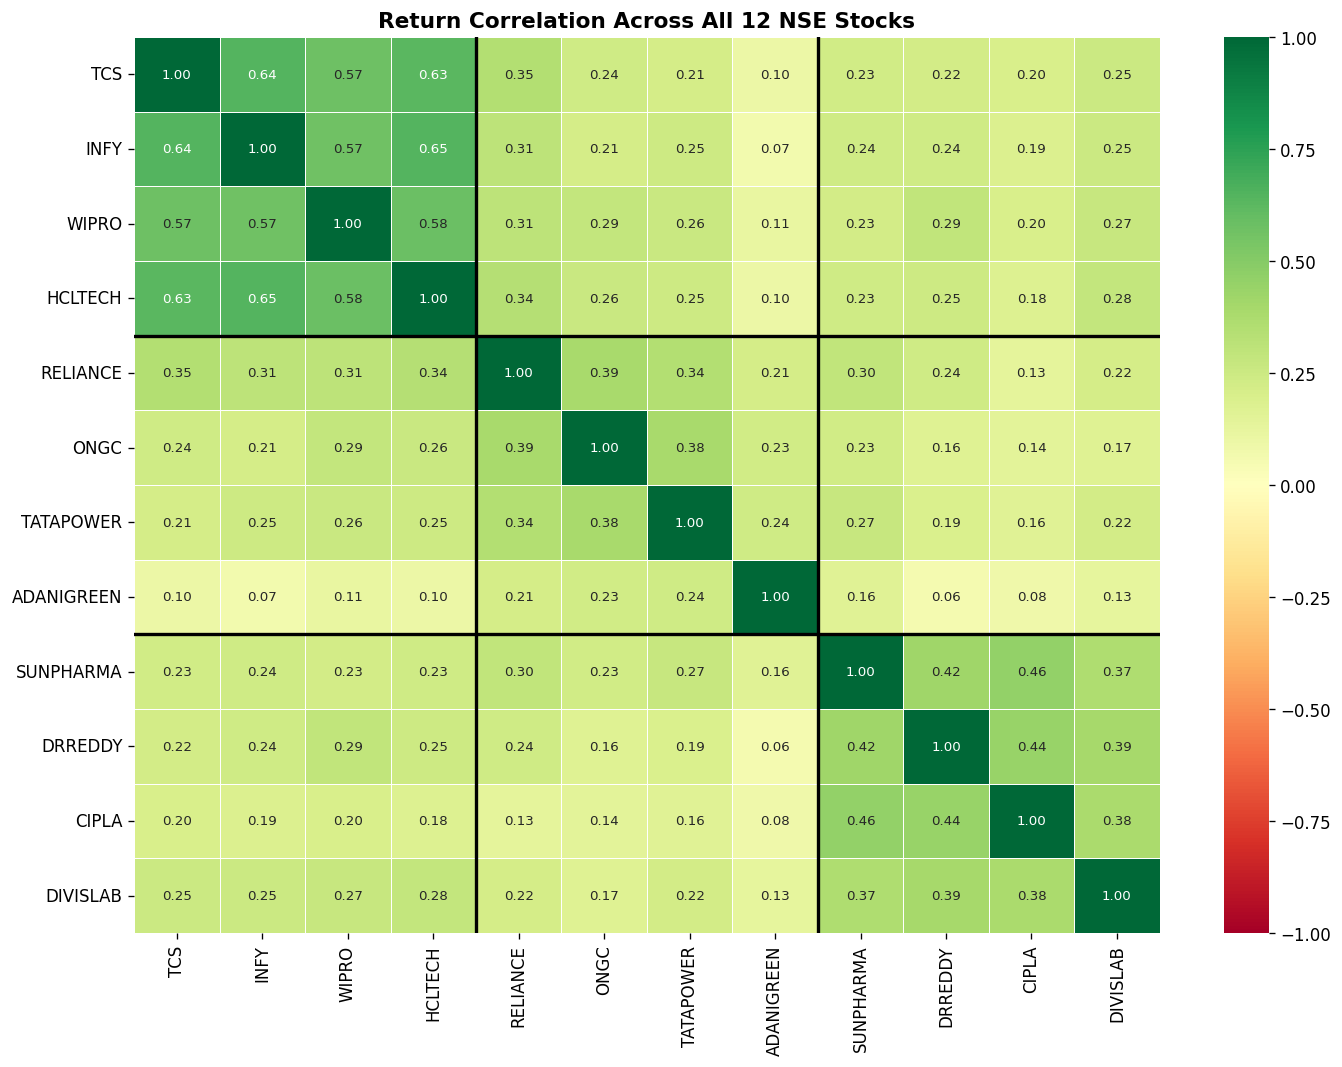

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = log_returns.corr()

corr.columns = [c.replace(".NS", "") for c in corr.columns]
corr.index   = [c.replace(".NS", "") for c in corr.index]

sector_order = (
    ["TCS", "INFY", "WIPRO", "HCLTECH"] +
    ["RELIANCE", "ONGC", "TATAPOWER", "ADANIGREEN"] +
    ["SUNPHARMA", "DRREDDY", "CIPLA", "DIVISLAB"]
)
corr = corr.loc[sector_order, sector_order]

sns.heatmap(
    corr,
    annot    = True,
    fmt      = ".2f",
    cmap     = "RdYlGn",
    center   = 0,
    vmin     = -1,
    vmax     = 1,
    ax       = ax,
    linewidths = 0.5,
    annot_kws = {"size": 8},
)

ax.set_title("Return Correlation Across All 12 NSE Stocks", fontsize=13, fontweight="bold")

for boundary in [4, 8]:
    ax.axhline(boundary, color="black", linewidth=2)
    ax.axvline(boundary, color="black", linewidth=2)

plt.tight_layout()
plt.savefig("logs/plots/correlation_heatmap.png", dpi=150)
plt.show()

### ESG scores vary significantly across sectors. All tech stocks clear the 0.6 threshold comfortably. ONGC (0.32) and Reliance (0.52) fall below it — this is exactly why the energy agent struggles with ESG compliance later. ADANIGREEN is the ESG standout in energy at 0.74.

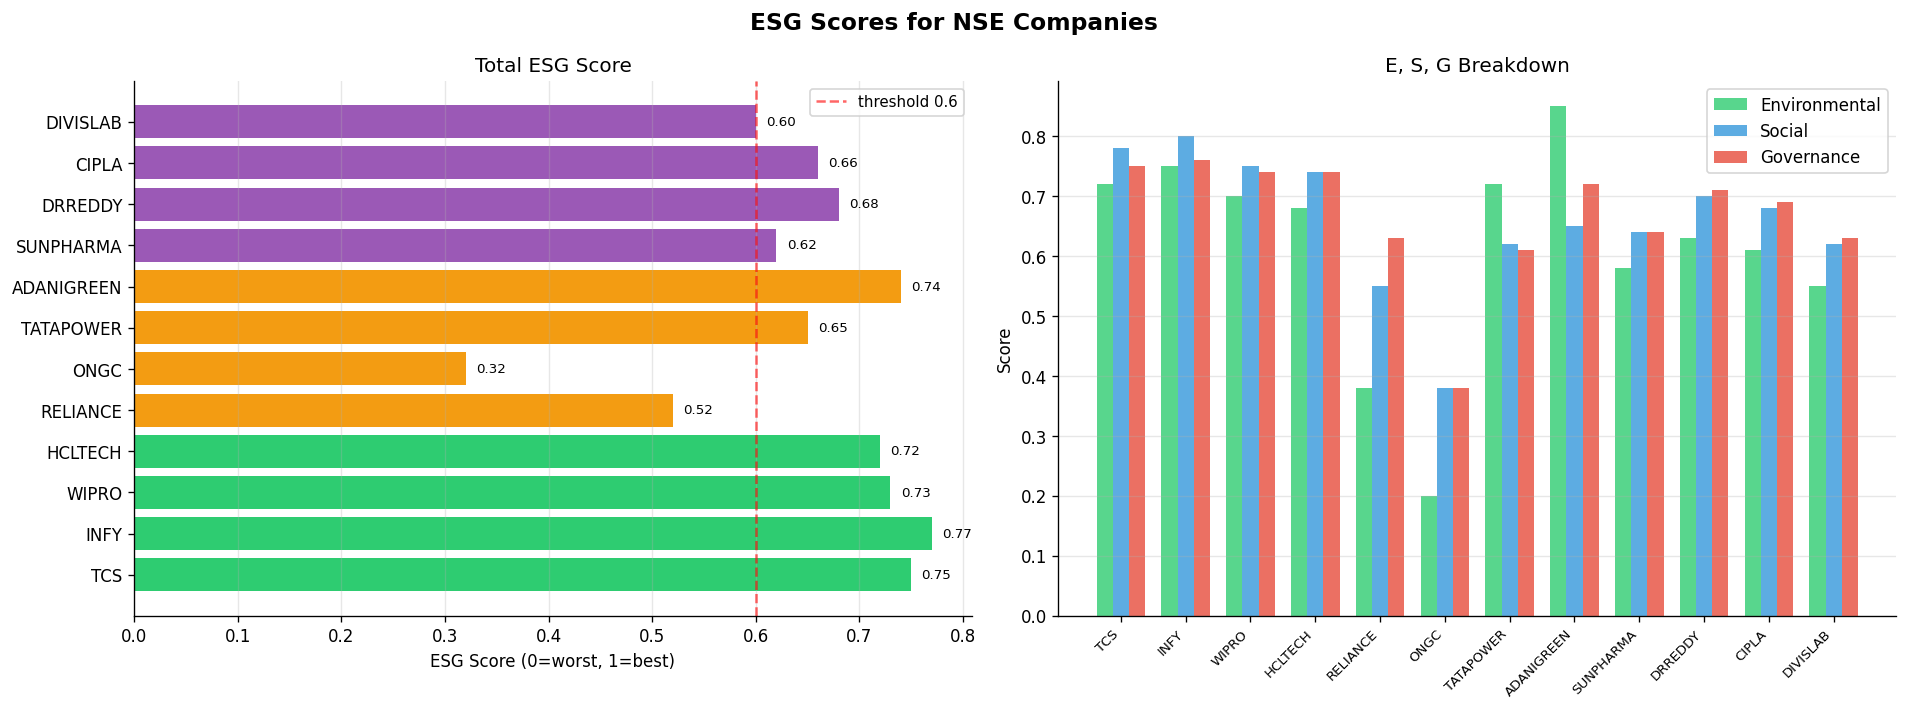

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ESG Scores for NSE Companies", fontsize=14, fontweight="bold")

# clean names for display
esg_plot = esg_df.copy()
esg_plot.index = [i.replace(".NS", "") for i in esg_plot.index]

sector_colors = (
    ["#2ECC71"] * 4 +   # tech
    ["#F39C12"] * 4 +   # energy
    ["#9B59B6"] * 4     # healthcare
)

# left plot — total ESG score
ax = axes[0]
bars = ax.barh(esg_plot.index, esg_plot["total"], color=sector_colors)
ax.set_xlabel("ESG Score (0=worst, 1=best)")
ax.set_title("Total ESG Score")
ax.axvline(0.6, color="red", linestyle="--", alpha=0.6, label="threshold 0.6")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

# add value labels
for bar, val in zip(bars, esg_plot["total"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=8)

# right plot — E, S, G breakdown
ax2 = axes[1]
x   = np.arange(len(esg_plot))
w   = 0.25

ax2.bar(x - w,   esg_plot["environmental"], w, label="Environmental", color="#2ECC71", alpha=0.8)
ax2.bar(x,       esg_plot["social"],        w, label="Social",        color="#3498DB", alpha=0.8)
ax2.bar(x + w,   esg_plot["governance"],    w, label="Governance",    color="#E74C3C", alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(esg_plot.index, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Score")
ax2.set_title("E, S, G Breakdown")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("logs/plots/esg_scores.png", dpi=150)
plt.show()

### Green region is training data (2019–2022), red is the test period (2023–2024). Agents never see the test period during training — this is a true out-of-sample evaluation.

Train days : 990  (2019-01-01 to 2022-12-31)
Test days  : 490   (2023-01-01 to 2024-12-30)


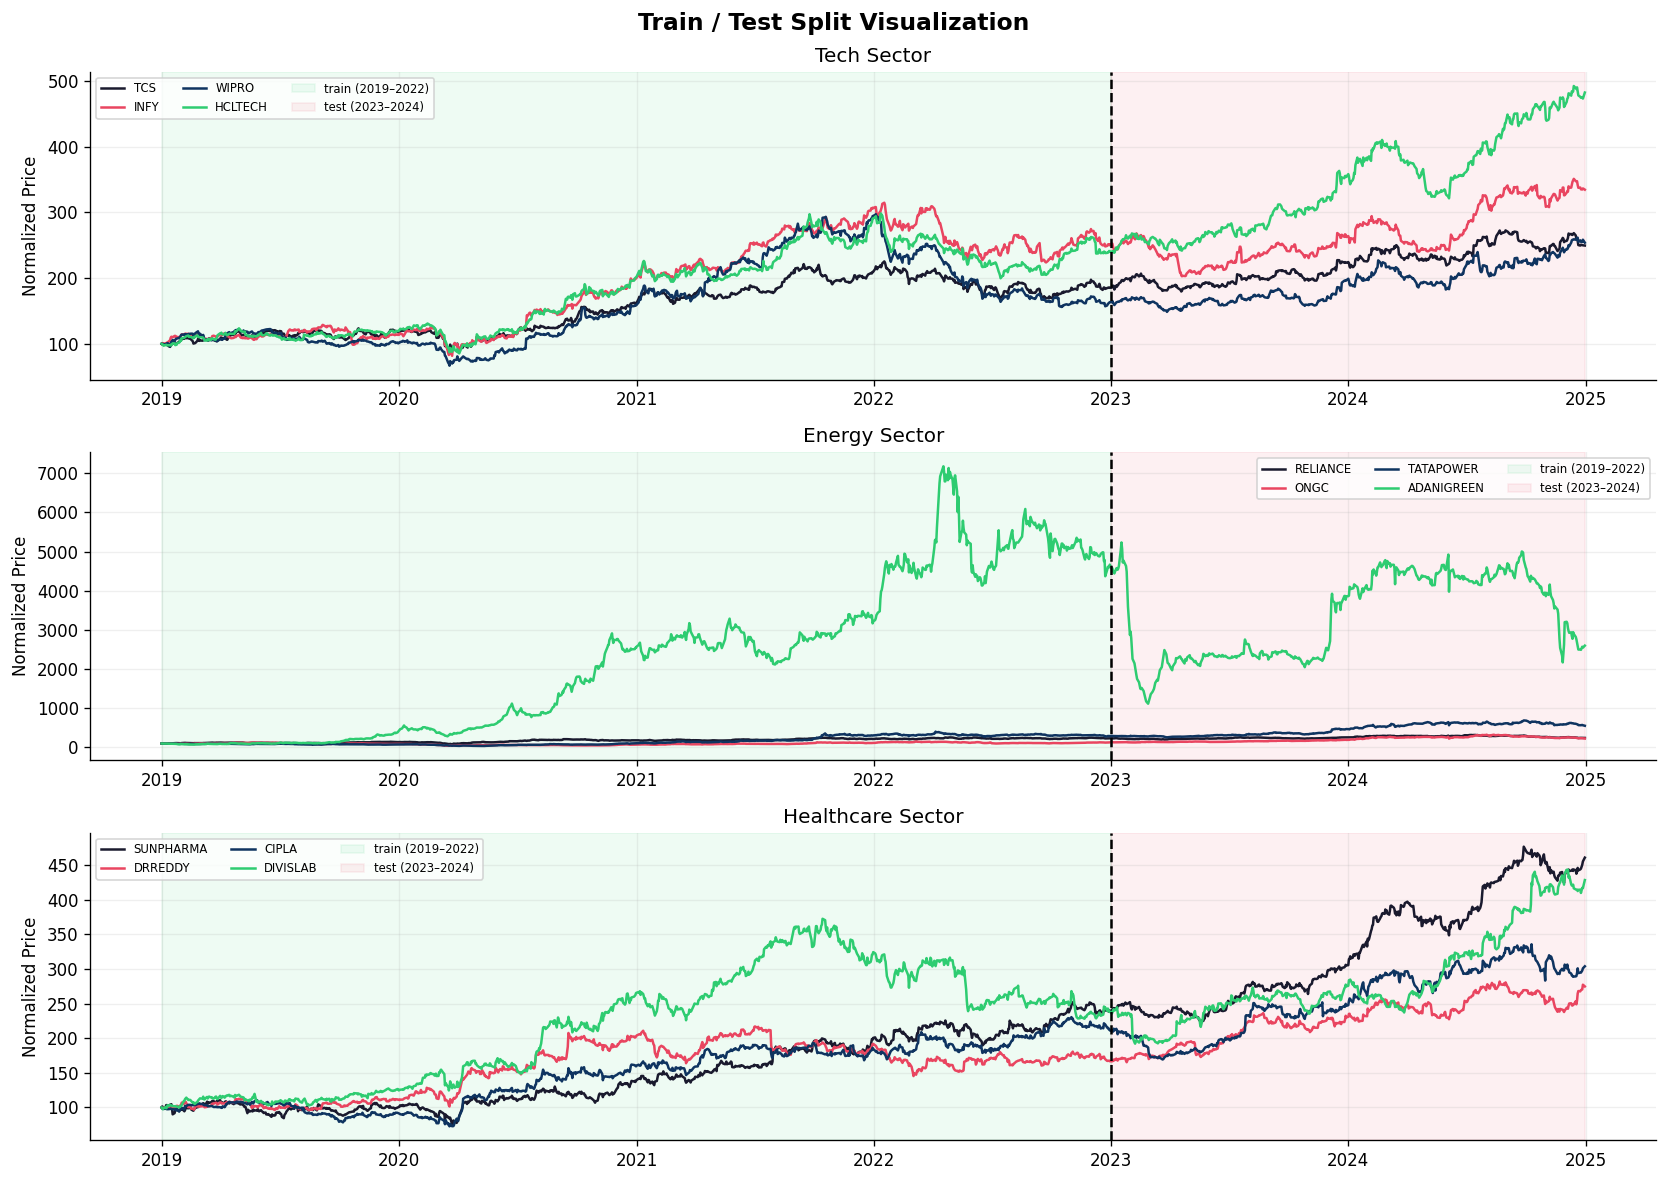

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Train / Test Split Visualization", fontsize=14, fontweight="bold")

split_date = pd.Timestamp("2023-01-01")

for ax, (sector, tickers) in zip(axes, sector_groups.items()):
    for ticker, color in zip(tickers, colors):
        normalized = prices[ticker] / prices[ticker].iloc[0] * 100
        ax.plot(normalized, color=color, linewidth=1.5,
                label=ticker.replace(".NS", ""))

    ax.axvspan(prices.index[0], split_date,
               alpha=0.08, color="#2ECC71", label="train (2019–2022)")
    ax.axvspan(split_date, prices.index[-1],
               alpha=0.08, color="#E94560", label="test (2023–2024)")
    ax.axvline(split_date, color="black", linewidth=1.5, linestyle="--")

    ax.set_title(f"{sector} Sector")
    ax.set_ylabel("Normalized Price")
    ax.legend(fontsize=7, ncol=3)
    ax.grid(alpha=0.2)

train_days = len(prices[prices.index < split_date])
test_days  = len(prices[prices.index >= split_date])
print(f"Train days : {train_days}  ({prices.index[0].date()} to 2022-12-31)")
print(f"Test days  : {test_days}   (2023-01-01 to {prices.index[-1].date()})")

plt.tight_layout()
plt.savefig("logs/plots/train_test_split.png", dpi=150)
plt.show()

### Processed data looks clean — 950 training days, 490 test days, zero NaNs. Each sample is a (20 days × 4 stocks × 5 features) window, exactly what the Transformer reads.

In [ ]:
with open("data/processed/train_data.pkl", "rb") as f:
    train_data = pickle.load(f)

with open("data/processed/test_data.pkl", "rb") as f:
    test_data = pickle.load(f)

print("Processed data shapes:\n")
for sector in train_data:
    tr = train_data[sector]
    te = test_data[sector]
    print(f"  {sector:<12} train X={tr['X'].shape}  test X={te['X'].shape}")
    print(f"             train y={tr['y'].shape}  test y={te['y'].shape}")
    print(f"             NaNs in train: {np.isnan(tr['X']).sum()}")
    print(f"             ESG scores: {tr['esg'].round(3)}")
    print()

Processed data shapes:

  tech         train X=(950, 20, 4, 5)  test X=(490, 20, 4, 5)
             train y=(950, 4)  test y=(490, 4)
             NaNs in train: 0
             ESG scores: [0.75 0.77 0.73 0.72]

  energy       train X=(950, 20, 4, 5)  test X=(490, 20, 4, 5)
             train y=(950, 4)  test y=(490, 4)
             NaNs in train: 0
             ESG scores: [0.52 0.32 0.65 0.74]

  healthcare   train X=(950, 20, 4, 5)  test X=(490, 20, 4, 5)
             train y=(950, 4)  test y=(490, 4)
             NaNs in train: 0
             ESG scores: [0.62 0.68 0.66 0.6 ]



### One actual input sample the Transformer sees — 20 days of 5 features per stock. The esg_score row is constant (static per stock). The red spikes in abs_return show high-volatility days the attention mechanism will learn to focus on.

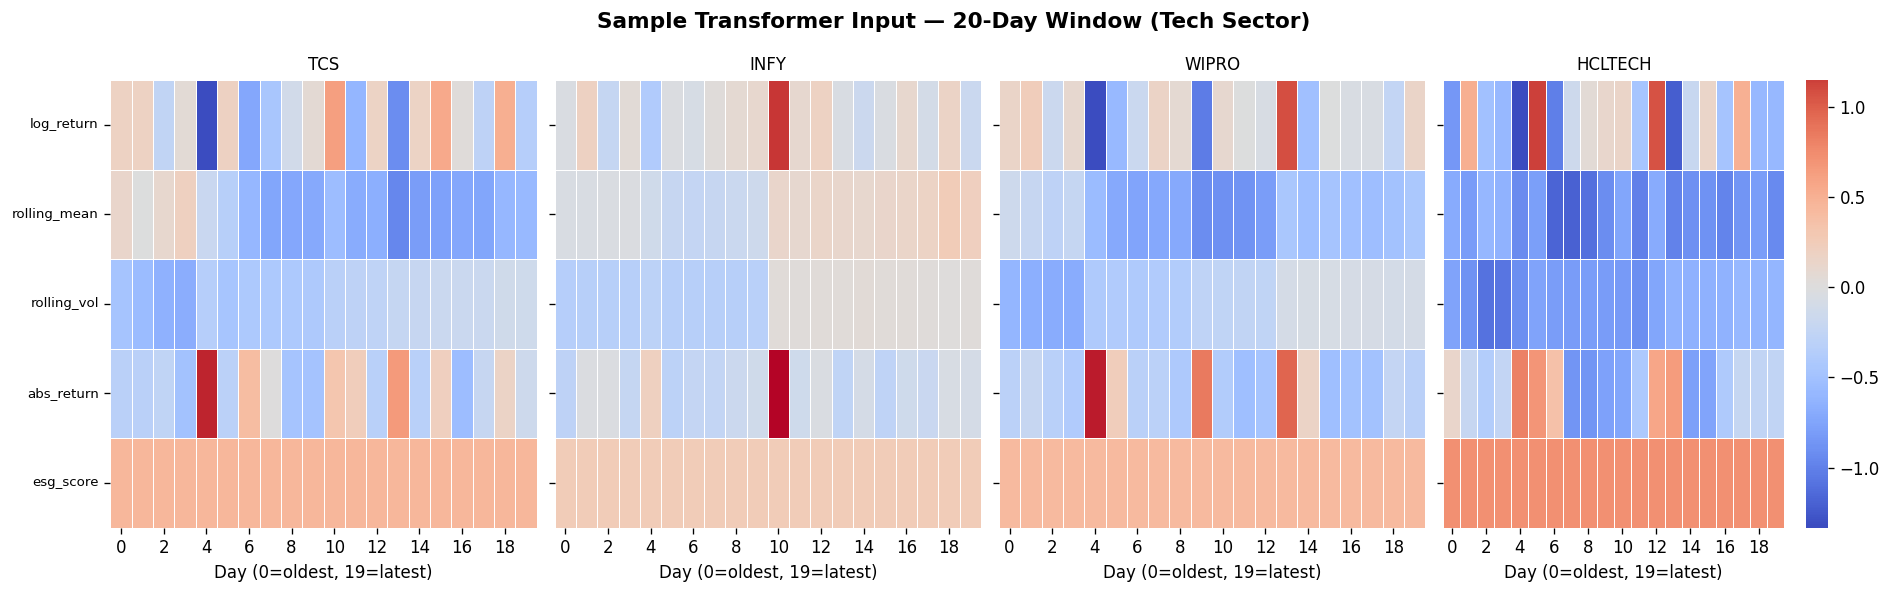

In [ ]:
sector   = "tech"
sample_X = train_data[sector]["X"][100]
tickers  = [t.replace(".NS", "") for t in train_data[sector]["tickers"]]
features = ["log_return", "rolling_mean", "rolling_vol", "abs_return", "esg_score"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Sample Transformer Input — 20-Day Window (Tech Sector)",
             fontsize=13, fontweight="bold")

for i, (ax, ticker) in enumerate(zip(axes, tickers)):
    df = pd.DataFrame(sample_X[:, i, :], columns=features)
    sns.heatmap(
        df.T,
        ax       = ax,
        cmap     = "coolwarm",
        center   = 0,
        linewidths = 0.3,
        cbar     = i == 3,
        annot    = False,
    )
    ax.set_title(ticker, fontsize=10)
    ax.set_xlabel("Day (0=oldest, 19=latest)")
    if i == 0:
        ax.set_yticklabels(features, rotation=0, fontsize=8)
    else:
        ax.set_yticklabels([])

plt.tight_layout()
plt.savefig("logs/plots/sample_window_heatmap.png", dpi=150)
plt.show()

## What We Found

- **Data is clean** — 1480 trading days, zero missing values, all 12 stocks have complete history from 2019 to 2024.

- **Sector separation makes sense** — within-sector correlations (0.57–0.65 for tech) are significantly higher than cross-sector correlations (0.06–0.35), which is exactly why we use 3 specialized agents instead of one.

- **ESG spread is meaningful** — scores range from 0.32 (ONGC) to 0.77 (Infosys). This spread is wide enough for the ESG penalty to actually change agent behavior. If all stocks had similar scores the penalty would be meaningless.

- **Energy sector is structurally challenging** — ONGC and Reliance drag the sector average ESG to 0.558, below our 0.6 threshold. An agent managing energy stocks needs to heavily favor ADANIGREEN and TATAPOWER to stay compliant — a real tension between diversification and ESG.

- **Transformer input looks good** — features are well normalized, no extreme outliers, clear patterns in volatility spikes that attention can learn to weight.

Everything checks out. Moving to PINN validation next.